['baselines.py', 'CNN.ipynb', 'config.py', 'data_pipeline.py', 'evaluation.py', 'Modelo por modelo.ipynb', 'models', 'plotting.py', 'portfolio.py', 'results', '__init__.py', '__pycache__']
Cargando datos...


[*********************100%***********************]  23 of 23 completed


Datos cargados: 16195 días, 23 activos
Rango: 1962-01-03 → 2026-05-08
Ventana entrada=5, salida=5
  X_train: (14567, 5, 23) | y_train: (14567, 23)
  X_test:  (1619, 5, 23)  | y_test:  (1619, 23)

  Modelo: CNN_f256_k3_in5_out5_GAP
  Parámetros: 382,231


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 5, 256)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 2, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 2, 256)         │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 23)             │         2,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 382,231 (1.46 MB)

 Trainable params: 382,231 (1.46 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
3278/3278 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 0.0055 - val_loss: 0.0055
Epoch 2/100
3278/3278 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 0.0055 - val_loss: 0.0055
Epoch 3/100
3278/3278 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 0.0055 - val_loss: 0.0055
Epoch 4/100
3278/3278 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 0.0055 - val_loss: 0.0055
Epoch 5/100
3278/3278 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 0.0055 - val_loss: 0.0055
Epoch 6/100
3278/3278 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 0.0055 - val_loss: 0.0055
Epoch 7/100
3278/3278 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 0.0055 - val_loss: 0.0055
Epoch 8/100
3278/3278 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 0.0055 - val_loss: 0.0055
Epoch 9/100
3278/3278 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 0.0054 - val_loss: 0.0055
Epoch 10/100
3278/3278 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 0.0055 - val_loss: 0.0055
Epoch 11/100
3278/3278 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 0.0055 - val_loss: 0.0055
Epoch 12/100
3278/3

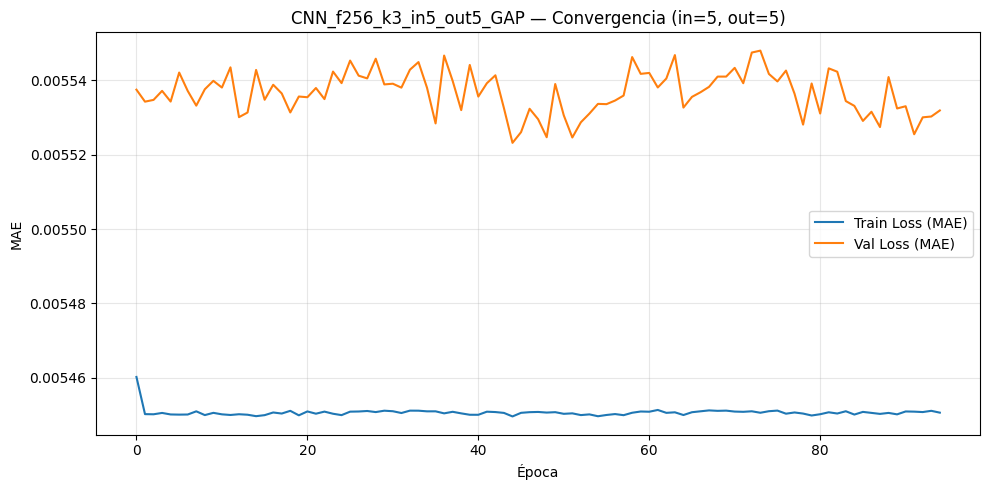

Modelo guardado en: models/CNN_f256_k3_in5_out5_GAP.keras


In [1]:
"""
cnn_model_single.py — Entrenamiento de CNN para UNA combinación de ventanas
=============================================================================

Cambia los parámetros en la sección CONFIGURACIÓN y ejecuta.
"""
import os
os.chdir(r'C:\Users\eneko\OneDrive\Escritorio\MIAX\Practica Redes')  # ← pon tu ruta real
print(os.listdir())  # verifica que ves config.py
import numpy as np
import os
import sys
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = os.getcwd()
sys.path.insert(0, PROJECT_ROOT)

from config import RANDOM_SEED, MODELS_DIR, FIGURES_DIR
from data_pipeline import load_data, get_train_test
from evaluation import compute_mae, save_results, count_parameters
from plotting import plot_training_curves

np.random.seed(RANDOM_SEED)
import tensorflow as tf
tf.random.set_seed(RANDOM_SEED)

from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, GlobalAveragePooling1D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam


# ============================================================================
# ▶▶▶ CONFIGURACIÓN — CAMBIA AQUÍ LOS PARÁMETROS ◀◀◀
# ============================================================================

INPUT_WINDOW = 5          # Ventana de entrada: 5, 10, 30 o 90
OUTPUT_WINDOW = 5         # Ventana de salida: 1, 5, 30 o 90

FILTERS = 256              # Filtros primera capa Conv1D
KERNEL_SIZE = 3           # Tamaño del kernel primera capa Conv1D
PADDING = 'same'         # 'same' o 'valid'
POOL_SIZE = 2             # MaxPooling pool_size primera capa

FILTERS_2 = 256            # Filtros segunda capa Conv1D (poner 0 para no usarla)
KERNEL_SIZE_2 = 3         # Tamaño del kernel segunda capa Conv1D

USE_GAP = True           # True → GlobalAveragePooling1D; False → Flatten

DENSE_1 = 256              # Neuronas primera capa densa
DENSE_2 = 256              # Neuronas segunda capa densa (poner 0 para no usarla)
DENSE_3 = 128               # Neuronas tercera capa densa (poner 0 para no usarla)
DROPOUT_RATE = 0.0        # Dropout (poner 0 para desactivar)

LEARNING_RATE = 0.001
EPOCHS = 100
BATCH_SIZE = 4
PATIENCE = 50
VALIDATION_SPLIT = 0.1

MODEL_NAME = f"CNN_f{FILTERS}_k{KERNEL_SIZE}_in{INPUT_WINDOW}_out{OUTPUT_WINDOW}{'_GAP' if USE_GAP else ''}"


# ============================================================================
# CONSTRUCCIÓN DEL MODELO
# ============================================================================

def build_cnn(input_window, n_features=23):
    layers = [
        Conv1D(FILTERS, kernel_size=KERNEL_SIZE, activation='relu',
               input_shape=(input_window, n_features), padding=PADDING),
        MaxPooling1D(pool_size=POOL_SIZE),
    ]

    if FILTERS_2 > 0:
        # padding='same' para evitar reducción de dimensión con ventanas pequeñas
        layers.append(Conv1D(FILTERS_2, kernel_size=KERNEL_SIZE_2, activation='relu', padding='same'))

    layers.append(GlobalAveragePooling1D() if USE_GAP else Flatten())

    layers.append(Dense(DENSE_1, activation='relu'))

    if DROPOUT_RATE > 0:
        layers.append(Dropout(DROPOUT_RATE))

    if DENSE_2 > 0:
        layers.append(Dense(DENSE_2, activation='relu'))
        if DROPOUT_RATE > 0:
            layers.append(Dropout(DROPOUT_RATE))

    if DENSE_3 > 0:
        layers.append(Dense(DENSE_3, activation='relu'))
        if DROPOUT_RATE > 0:
            layers.append(Dropout(DROPOUT_RATE))

    layers.append(Dense(n_features))

    model = Sequential(layers)
    model.compile(optimizer=Adam(learning_rate=LEARNING_RATE), loss='mae')
    return model


# ============================================================================
# ENTRENAMIENTO
# ============================================================================

print("Cargando datos...")
returns = load_data()

X_train, X_test, y_train, y_test = get_train_test(returns, INPUT_WINDOW, OUTPUT_WINDOW)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=VALIDATION_SPLIT,
    shuffle=True,
    random_state=RANDOM_SEED
)

model = build_cnn(INPUT_WINDOW, n_features=X_train.shape[2])
n_params = count_parameters(model)

print(f"\n{'='*60}")
print(f"  Modelo: {MODEL_NAME}")
print(f"  Parámetros: {n_params:,}")
print(f"{'='*60}")
model.summary()

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=PATIENCE,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_tr, y_tr,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)


# ============================================================================
# EVALUACIÓN
# ============================================================================

y_pred_train = model.predict(X_train, verbose=0)
y_pred_test = model.predict(X_test, verbose=0)

mae_train = compute_mae(y_train, y_pred_train)
mae_test = compute_mae(y_test, y_pred_test)
mae_val = min(history.history['val_loss'])

print(f"\n{'='*60}")
print(f"  Resultados {MODEL_NAME}:")
print(f"    MAE Train: {mae_train:.6f}")
print(f"    MAE Val:   {mae_val:.6f}")
print(f"    MAE Test:  {mae_test:.6f}")
print(f"{'='*60}")

save_results(
    model_name=MODEL_NAME,
    model_type='convolutional',
    input_window=INPUT_WINDOW,
    output_window=OUTPUT_WINDOW,
    mae_train=mae_train,
    mae_test=mae_test,
    n_params=n_params,
    mae_val=mae_val
)

plot_training_curves(history, MODEL_NAME, INPUT_WINDOW, OUTPUT_WINDOW, save=True)

os.makedirs(MODELS_DIR, exist_ok=True)
model.save(os.path.join(MODELS_DIR, f"{MODEL_NAME}.keras"))
print(f"Modelo guardado en: {MODELS_DIR}{MODEL_NAME}.keras")